In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
years = [2014, 2015, 2016, 2017]
keys = ["obs", "cas7_t1_x11ab", "ssc"]

data_list = []
for yy in years:
    fn = f"./combined_bottle_{yy}_cas7_t1_x11ab_ssc.pkl"
    data_list.append(pd.read_pickle(fn))

# concatenate for each key
data_all = {}
for k in keys:
    data_all[k] = pd.concat([d[k] for d in data_list], ignore_index=True)

print(data_all.keys())
print("obs:", data_all["obs"].shape)
print("cas7_t1_x11ab:", data_all["cas7_t1_x11ab"].shape)
print("ssc:", data_all["ssc"].shape)

dict_keys(['obs', 'cas7_t1_x11ab', 'ssc'])
obs: (20078, 19)
cas7_t1_x11ab: (20078, 16)
ssc: (20825, 16)


In [ ]:
data = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")

In [9]:
print(list(data_all.keys()))

['obs', 'cas7_t1_x11ab', 'ssc']


In [19]:
print(data_all["obs"].columns)
print(data_all["cas7_t1_x11ab"].columns)
print(data_all["ssc"].columns)

Index(['cid', 'lon', 'lat', 'time', 'z', 'SA', 'CT', 'DO', 'NO3', 'Chl',
       'name', 'cruise', 'source', 'NH4', 'PO4 (uM)', 'SiO4 (uM)', 'NO2 (uM)',
       'TA', 'DIC'],
      dtype='object')
Index(['time', 'lat', 'lon', 'z', 'cid', 'cruise', 'name', 'source', 'CT',
       'SA', 'DO', 'Chl', 'NO3', 'NH4', 'TA', 'DIC'],
      dtype='object')
Index(['time', 'lat', 'lon', 'z', 'NO3', 'silicon', 'NH4', 'DIAT', 'FLAG',
       'SA', 'CT', 'TA', 'DIC', 'DO', 'name', 'cid'],
      dtype='object')


In [62]:
# Selected stations
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

obs = data["obs"]

for station in station_names:

    # Filter to station
    obs_s = obs[obs["name"] == station]

    # Get unique depths
    depths = np.sort(obs_s["z"].dropna().unique())

    print(f"\n{station}")
    print(depths)


SAR003
[-106.   -30.5  -11.   -10.5  -10.    -2.    -1.5   -1. ]

PSS019
[-83.5 -30.5 -11.  -10.5 -10.   -2.   -1.5  -1. ]

SKG003
[-11.  -10.5 -10.   -2.   -1.5  -1. ]

HCB004
[-30.5 -30.  -11.  -10.5 -10.   -1.5  -1. ]

HCB003
[-95.  -30.5 -30.  -11.  -10.5 -10.   -1.5  -1. ]

ADM003
[-203.  -198.  -189.5 -184.5 -172.5  -30.5  -10.5  -10.    -1.5   -1. ]

CMB003
[-148.5  -30.5  -30.   -11.   -10.5  -10.    -1.5   -1. ]

GOR001
[-162.   -30.5  -11.   -10.5   -1.5   -1. ]

CSE001
[-34.  -30.5 -24.5 -11.  -10.5 -10.   -1.5  -1. ]

EAP001
[-152.   -30.5  -11.   -10.5  -10.    -1.5   -1. ]

SIN001
[-11.  -10.5 -10.   -1.5  -1. ]

PSB003
[-30.5 -30.  -21.  -17.5 -11.  -10.5 -10.   -1.5  -1. ]


/tmp/ipykernel_26396/274791915.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_s["time"] = pd.to_datetime(obs_s["time"])
/tmp/ipykernel_26396/274791915.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lo_s["time"] = pd.to_datetime(lo_s["time"])
/tmp/ipykernel_26396/274791915.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

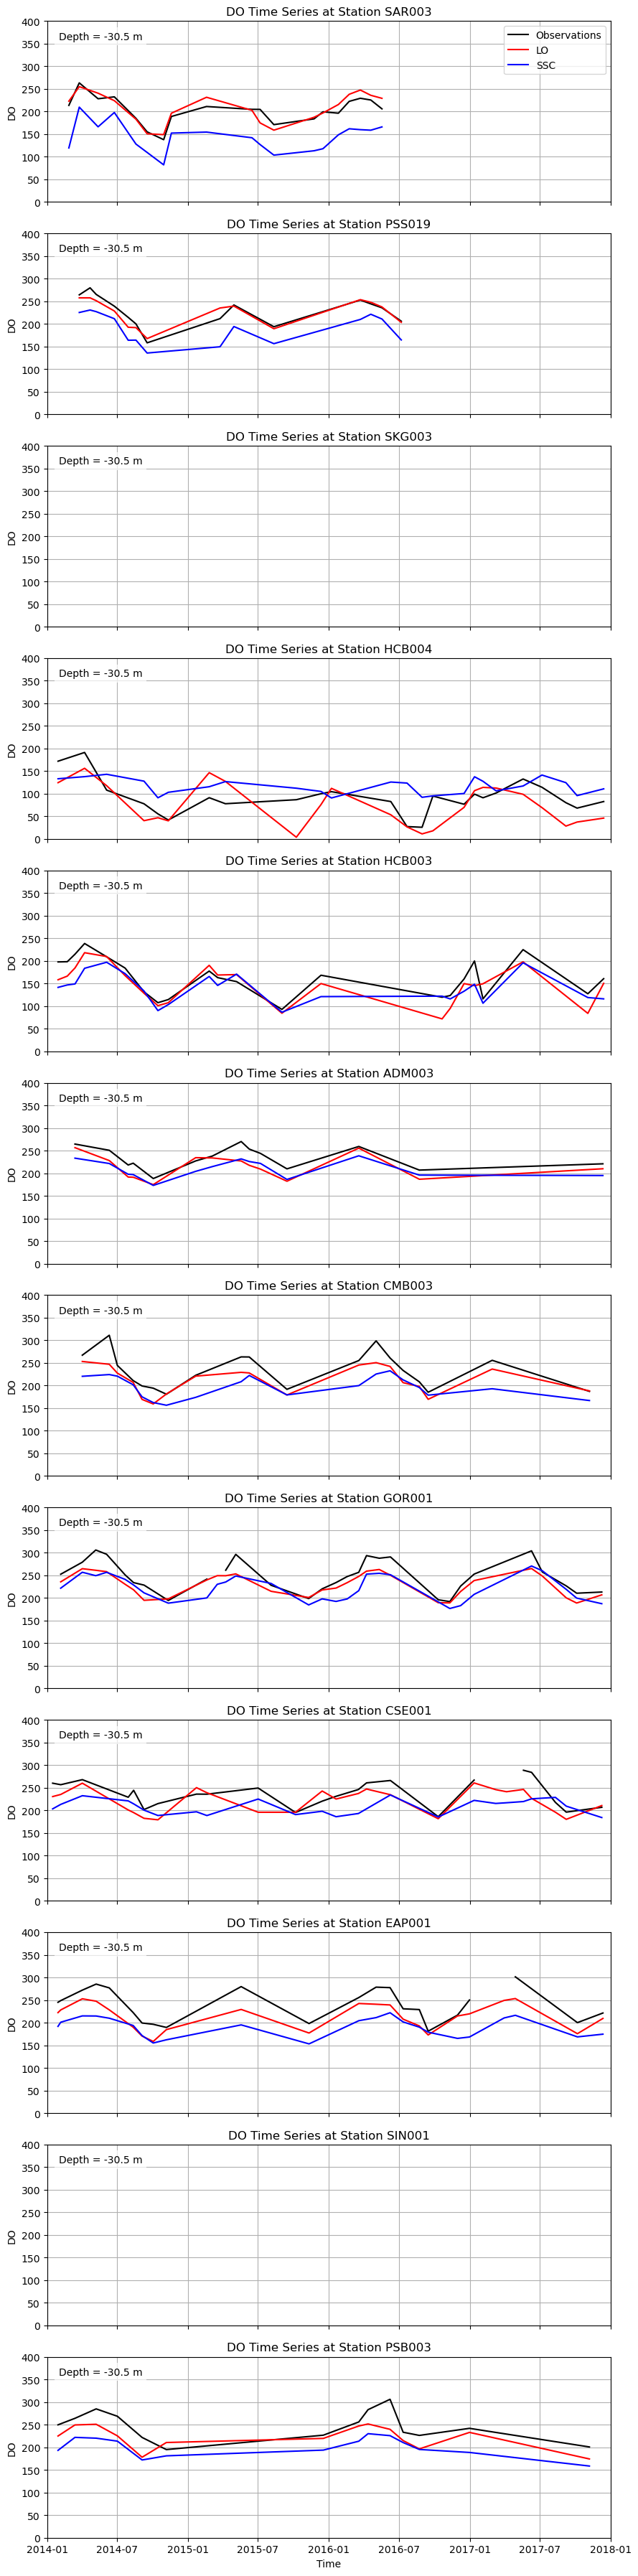

In [ ]:
# DO

# choose stations
# station_names = ['SAR003', 'SKG003', 'PSS019']  # whidbey basin
# station_names = ['SAR003', 'PSS019']  # whidbey basin
# station_names = ['HCB004', 'HCB007', 'HCB003', 'HCB010'] # hood canal
# station_names = ['HCB004', 'HCB003', 'HCB010'] # hood canal
# station_names = ['ADM001', 'ADM003', 'PSB003', 'SIN001', 'ELB015', 'EAP001'] # main basin
# station_names = ['ADM003', 'PSB003', 'ELB015', 'EAP001'] # main basin
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"] 
                 
obs = data_all["obs"]
lo = data_all["cas7_t1_x11ab"]
ssc = data_all["ssc"]

depth = -30.5 # select depth

# Create subplots (one row per station)
fig, axes = plt.subplots(len(station_names), 1, figsize=(9, 3*len(station_names)), sharex=True)

# If only one station, make axes iterable
if len(station_names) == 1:
    axes = [axes]

for ax, station_name in zip(axes, station_names):

    # Filter observations for this station
    obs_s = obs[obs["name"] == station_name]

    if obs_s.empty:
        print(f"No data for station {station_name}")
        continue

    lat = obs_s["lat"].values[0]
    lon = obs_s["lon"].values[0]

    # Filter model datasets by lat/lon
    lo_s = lo[(lo["lat"] == lat) & (lo["lon"] == lon)]
    ssc_s = ssc[(ssc["lat"] == lat) & (ssc["lon"] == lon)]

    # Convert time
    obs_s["time"] = pd.to_datetime(obs_s["time"])
    lo_s["time"] = pd.to_datetime(lo_s["time"])
    ssc_s["time"] = pd.to_datetime(ssc_s["time"])

    # Select depth
    obs_s = obs_s[obs_s["z"] == depth]
    lo_s = lo_s[lo_s["z"] == depth]
    ssc_s = ssc_s[ssc_s["z"] == depth]

    # Sort by time
    obs_s = obs_s.sort_values("time")
    lo_s = lo_s.sort_values("time")
    ssc_s = ssc_s.sort_values("time")

    # Plot
    ax.plot(obs_s["time"], obs_s["DO"], label="Observations", color='k')
    ax.plot(lo_s["time"], lo_s["DO"], label="LO", color='r')
    ax.plot(ssc_s["time"], ssc_s["DO"], label="SSC", color='b')
    
    ax.text(
    0.02, 0.9,
    f"Depth = {depth} m",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
    ax.set_xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2018-01-01"))
    ax.set_ylim(0, 400)

    ax.set_title(f"DO Time Series at Station {station_name}")
    ax.set_ylabel("DO")
    ax.grid(True)

# Common x-label
axes[-1].set_xlabel("Time")

# Single legend (from first subplot)
axes[0].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_26396/3068470171.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_s["time"] = pd.to_datetime(obs_s["time"])
/tmp/ipykernel_26396/3068470171.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lo_s["time"] = pd.to_datetime(lo_s["time"])
/tmp/ipykernel_26396/3068470171.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

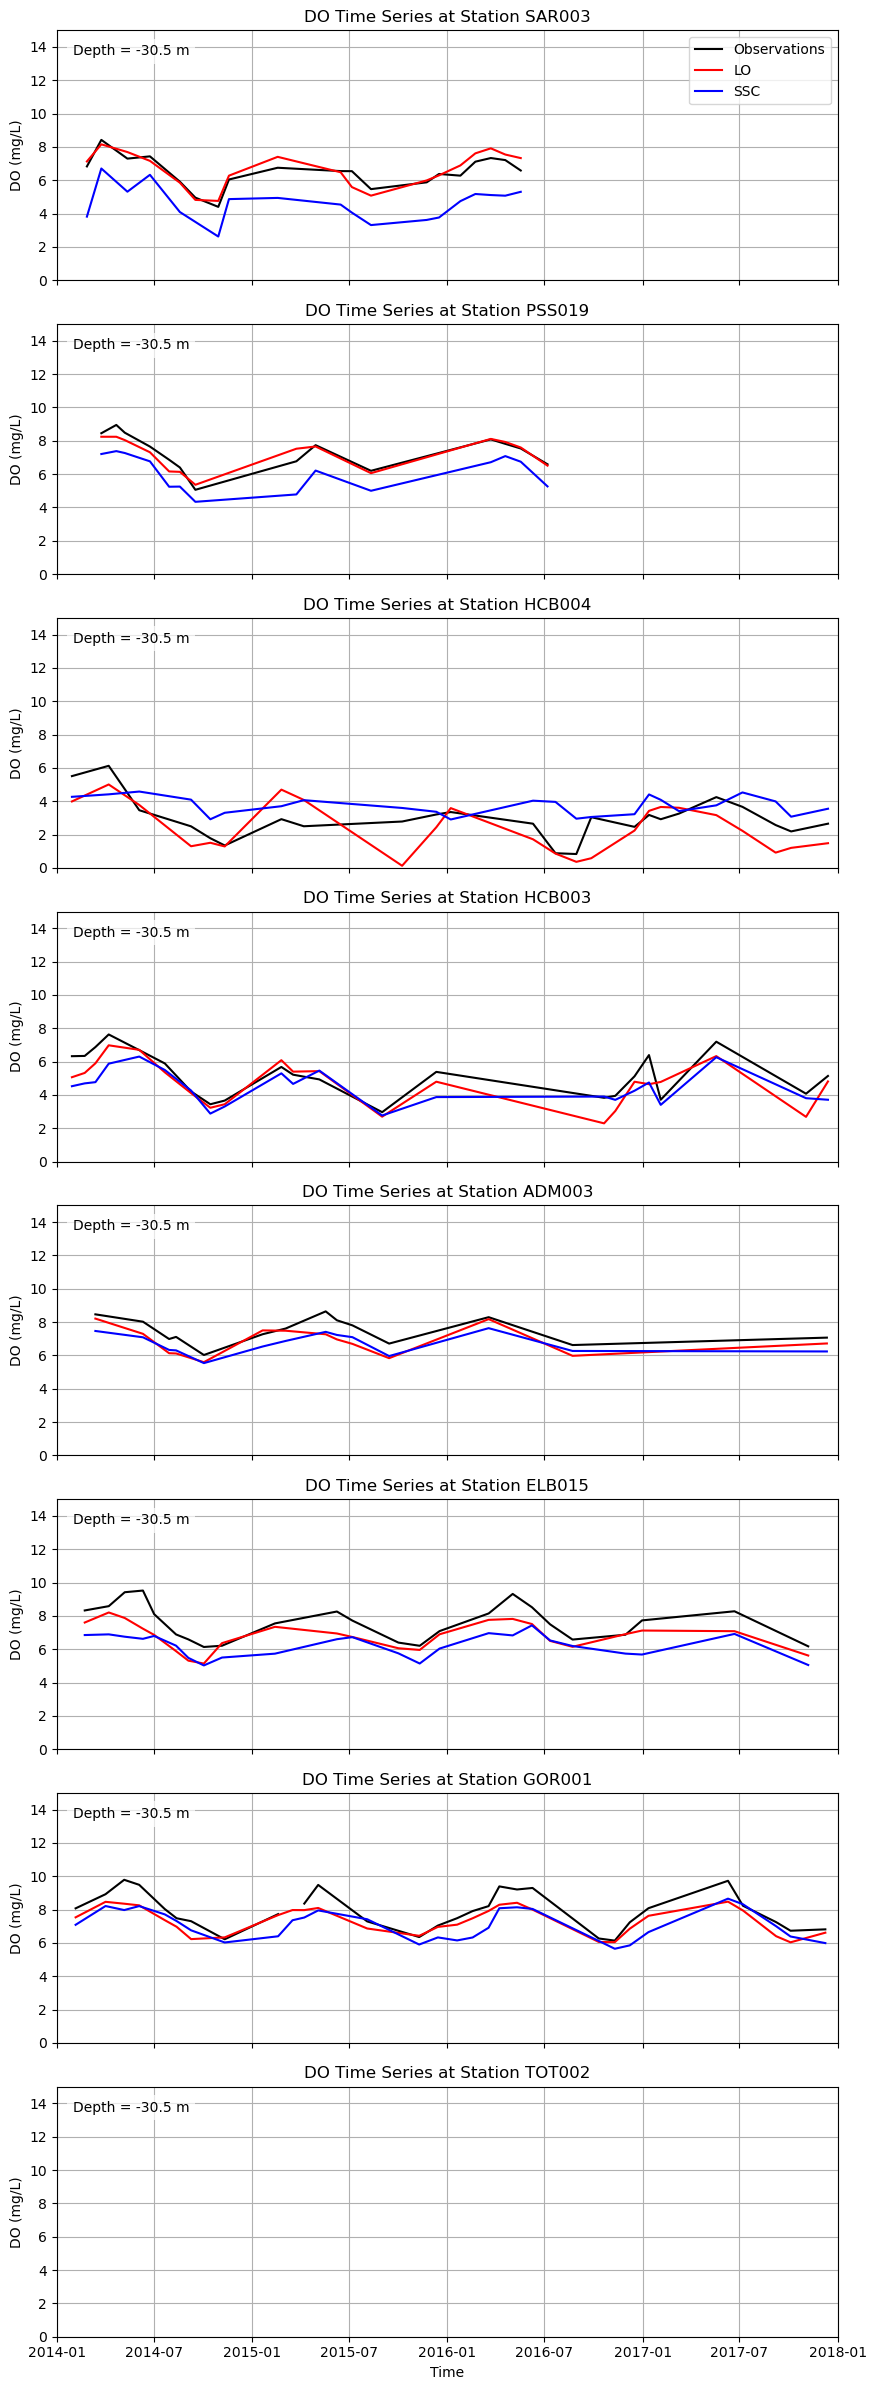

In [ ]:
# DO mg/L

# choose stations
# station_names = ['SAR003', 'SKG003', 'PSS019']  # whidbey basin
# station_names = ['SAR003', 'PSS019']  # whidbey basin
# station_names = ['HCB004', 'HCB007', 'HCB003', 'HCB010'] # hood canal
# station_names = ['HCB004', 'HCB003', 'HCB010'] # hood canal
# station_names = ['ADM001', 'ADM003', 'PSB003', 'SIN001', 'ELB015', 'EAP001'] # main basin
# station_names = ['ADM003', 'PSB003', 'ELB015', 'EAP001'] # main basin
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]
                 
obs = data_all["obs"]
lo = data_all["cas7_t1_x11ab"]
ssc = data_all["ssc"]

depth = -30.5 # select depth

# Create subplots (one row per station)
fig, axes = plt.subplots(len(station_names), 1, figsize=(9, 3*len(station_names)), sharex=True)

# If only one station, make axes iterable
if len(station_names) == 1:
    axes = [axes]

for ax, station_name in zip(axes, station_names):

    # Filter observations for this station
    obs_s = obs[obs["name"] == station_name]

    if obs_s.empty:
        print(f"No data for station {station_name}")
        continue

    lat = obs_s["lat"].values[0]
    lon = obs_s["lon"].values[0]

    # Filter model datasets by lat/lon
    lo_s = lo[(lo["lat"] == lat) & (lo["lon"] == lon)]
    ssc_s = ssc[(ssc["lat"] == lat) & (ssc["lon"] == lon)]

    # Convert time
    obs_s["time"] = pd.to_datetime(obs_s["time"])
    lo_s["time"] = pd.to_datetime(lo_s["time"])
    ssc_s["time"] = pd.to_datetime(ssc_s["time"])
    
    # convert DO from umol/L to mg/L
    obs_s["DO_mgL"] = obs_s["DO"] * 32 / 1000
    lo_s["DO_mgL"]  = lo_s["DO"]  * 32 / 1000
    ssc_s["DO_mgL"] = ssc_s["DO"] * 32 / 1000

    # Select depth
    obs_s = obs_s[obs_s["z"] == depth]
    lo_s = lo_s[lo_s["z"] == depth]
    ssc_s = ssc_s[ssc_s["z"] == depth]

    # Sort by time
    obs_s = obs_s.sort_values("time")
    lo_s = lo_s.sort_values("time")
    ssc_s = ssc_s.sort_values("time")

    # Plot
    ax.plot(obs_s["time"], obs_s["DO_mgL"], label="Observations", color='k')
    ax.plot(lo_s["time"], lo_s["DO_mgL"], label="LO", color='r')
    ax.plot(ssc_s["time"], ssc_s["DO_mgL"], label="SSC", color='b')
    
    ax.text(
    0.02, 0.9,
    f"Depth = {depth} m",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
    ax.set_xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2018-01-01"))
    ax.set_ylim(0, 15)

    ax.set_title(f"DO Time Series at Station {station_name}")
    ax.set_ylabel("DO (mg/L)")
    ax.grid(True)

# Common x-label
axes[-1].set_xlabel("Time")

# Single legend (from first subplot)
axes[0].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_161951/2004567694.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_s["time"] = pd.to_datetime(obs_s["time"])
/tmp/ipykernel_161951/2004567694.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lo_s["time"] = pd.to_datetime(lo_s["time"])
/tmp/ipykernel_161951/2004567694.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

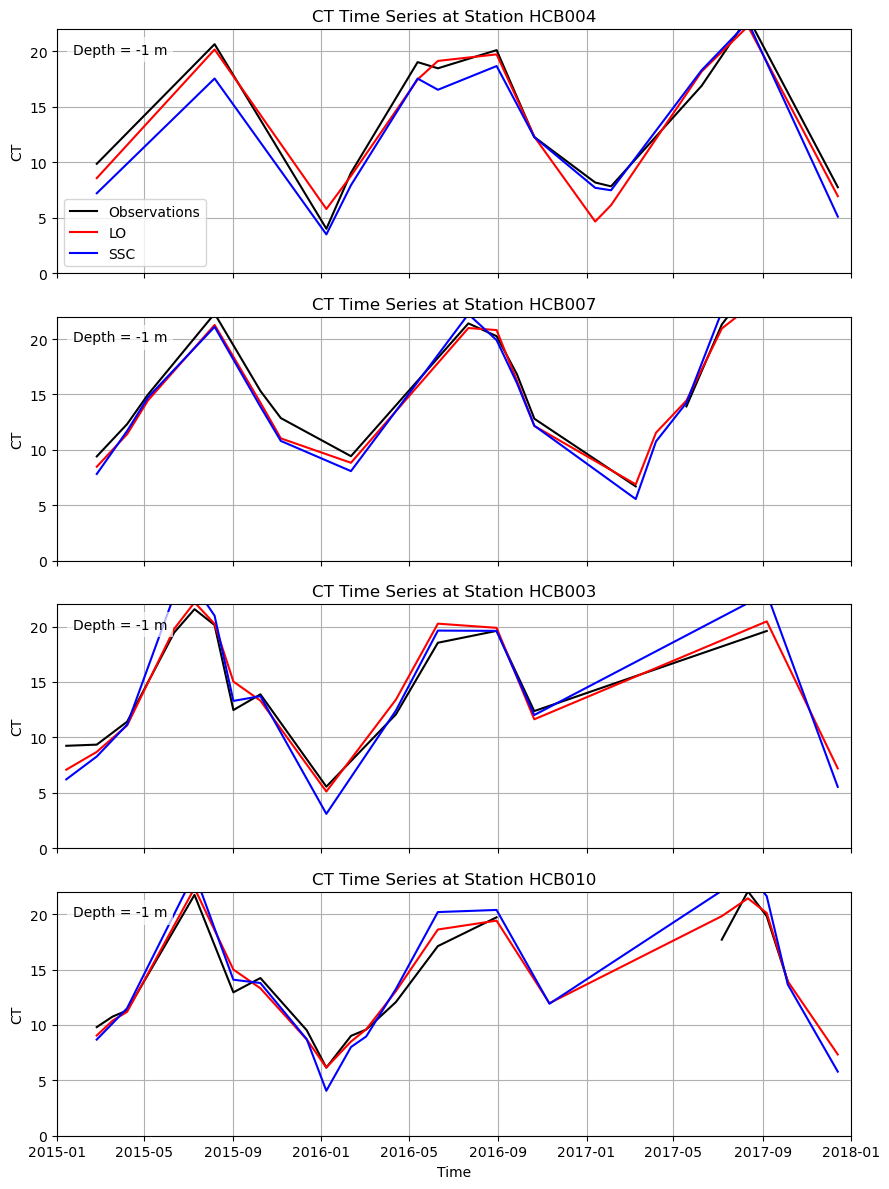

In [ ]:
# CT

# choose stations
# station_names = ['SAR003', 'SKG003', 'PSS019']  # whidbey basin
# station_names = ['SAR003', 'PSS019']  # whidbey basin
station_names = ['HCB004', 'HCB007', 'HCB003', 'HCB010'] # hood canal
# station_names = ['HCB004', 'HCB003', 'HCB010'] # hood canal
# station_names = ['ADM001', 'ADM003', 'PSB003', 'SIN001', 'ELB015', 'EAP001'] # main basin
# station_names = ['ADM003', 'PSB003', 'ELB015', 'EAP001'] # main basin
                 
obs = data_all["obs"]
lo = data_all["cas7_t1_x11ab"]
ssc = data_all["ssc"]

depth = -1 # select depth

# Create subplots (one row per station)
fig, axes = plt.subplots(len(station_names), 1, figsize=(9, 3*len(station_names)), sharex=True)

# If only one station, make axes iterable
if len(station_names) == 1:
    axes = [axes]

for ax, station_name in zip(axes, station_names):

    # Filter observations for this station
    obs_s = obs[obs["name"] == station_name]

    if obs_s.empty:
        print(f"No data for station {station_name}")
        continue

    lat = obs_s["lat"].values[0]
    lon = obs_s["lon"].values[0]

    # Filter model datasets by lat/lon
    lo_s = lo[(lo["lat"] == lat) & (lo["lon"] == lon)]
    ssc_s = ssc[(ssc["lat"] == lat) & (ssc["lon"] == lon)]

    # Convert time
    obs_s["time"] = pd.to_datetime(obs_s["time"])
    lo_s["time"] = pd.to_datetime(lo_s["time"])
    ssc_s["time"] = pd.to_datetime(ssc_s["time"])

    # Select depth
    obs_s = obs_s[obs_s["z"] == depth]
    lo_s = lo_s[lo_s["z"] == depth]
    ssc_s = ssc_s[ssc_s["z"] == depth]

    # Sort by time
    obs_s = obs_s.sort_values("time")
    lo_s = lo_s.sort_values("time")
    ssc_s = ssc_s.sort_values("time")

    # Plot
    ax.plot(obs_s["time"], obs_s["CT"], label="Observations", color='k')
    ax.plot(lo_s["time"], lo_s["CT"], label="LO", color='r')
    ax.plot(ssc_s["time"], ssc_s["CT"], label="SSC", color='b')
    
    ax.text(
    0.02, 0.9,
    f"Depth = {depth} m",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
    ax.set_xlim(pd.Timestamp("2015-01-01"), pd.Timestamp("2018-01-01"))
    ax.set_ylim(0, 22)


    ax.set_title(f"CT Time Series at Station {station_name}")
    ax.set_ylabel("CT")
    ax.grid(True)

# Common x-label
axes[-1].set_xlabel("Time")

# Single legend (from first subplot)
axes[0].legend()

plt.tight_layout()
plt.show()